In [1]:
import numpy as np
from sklearn . datasets import fetch_openml
from sklearn . model_selection import train_test_split
from sklearn . linear_model import LogisticRegression
from sklearn . multiclass import OneVsRestClassifier
from sklearn . multioutput import ClassifierChain
from sklearn . metrics import accuracy_score
from sklearn . metrics import hamming_loss
from sklearn . metrics import jaccard_score
X, Y = fetch_openml("emotions", version=4, return_X_y=True)
Y = (Y == "TRUE").astype(int)
X_train , X_test , Y_train , Y_test = train_test_split(
X, Y, test_size=0.3, random_state=42
)

# Task 1

In [6]:
from matplotlib import pyplot as plt
import seaborn as sns
def plot_correlation_matrix(m):
    plt.figure(figsize=(20, 15))
    sns.heatmap(m,
                annot=True,
                cmap='RdBu_r',  # Red-Blue is often more intuitive for +/- correlations
                center=0,  # Ensure 0 is the neutral color
                linewidths=.1,
                cbar_kws={"shrink": .8},
                vmin=-1, vmax=1)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

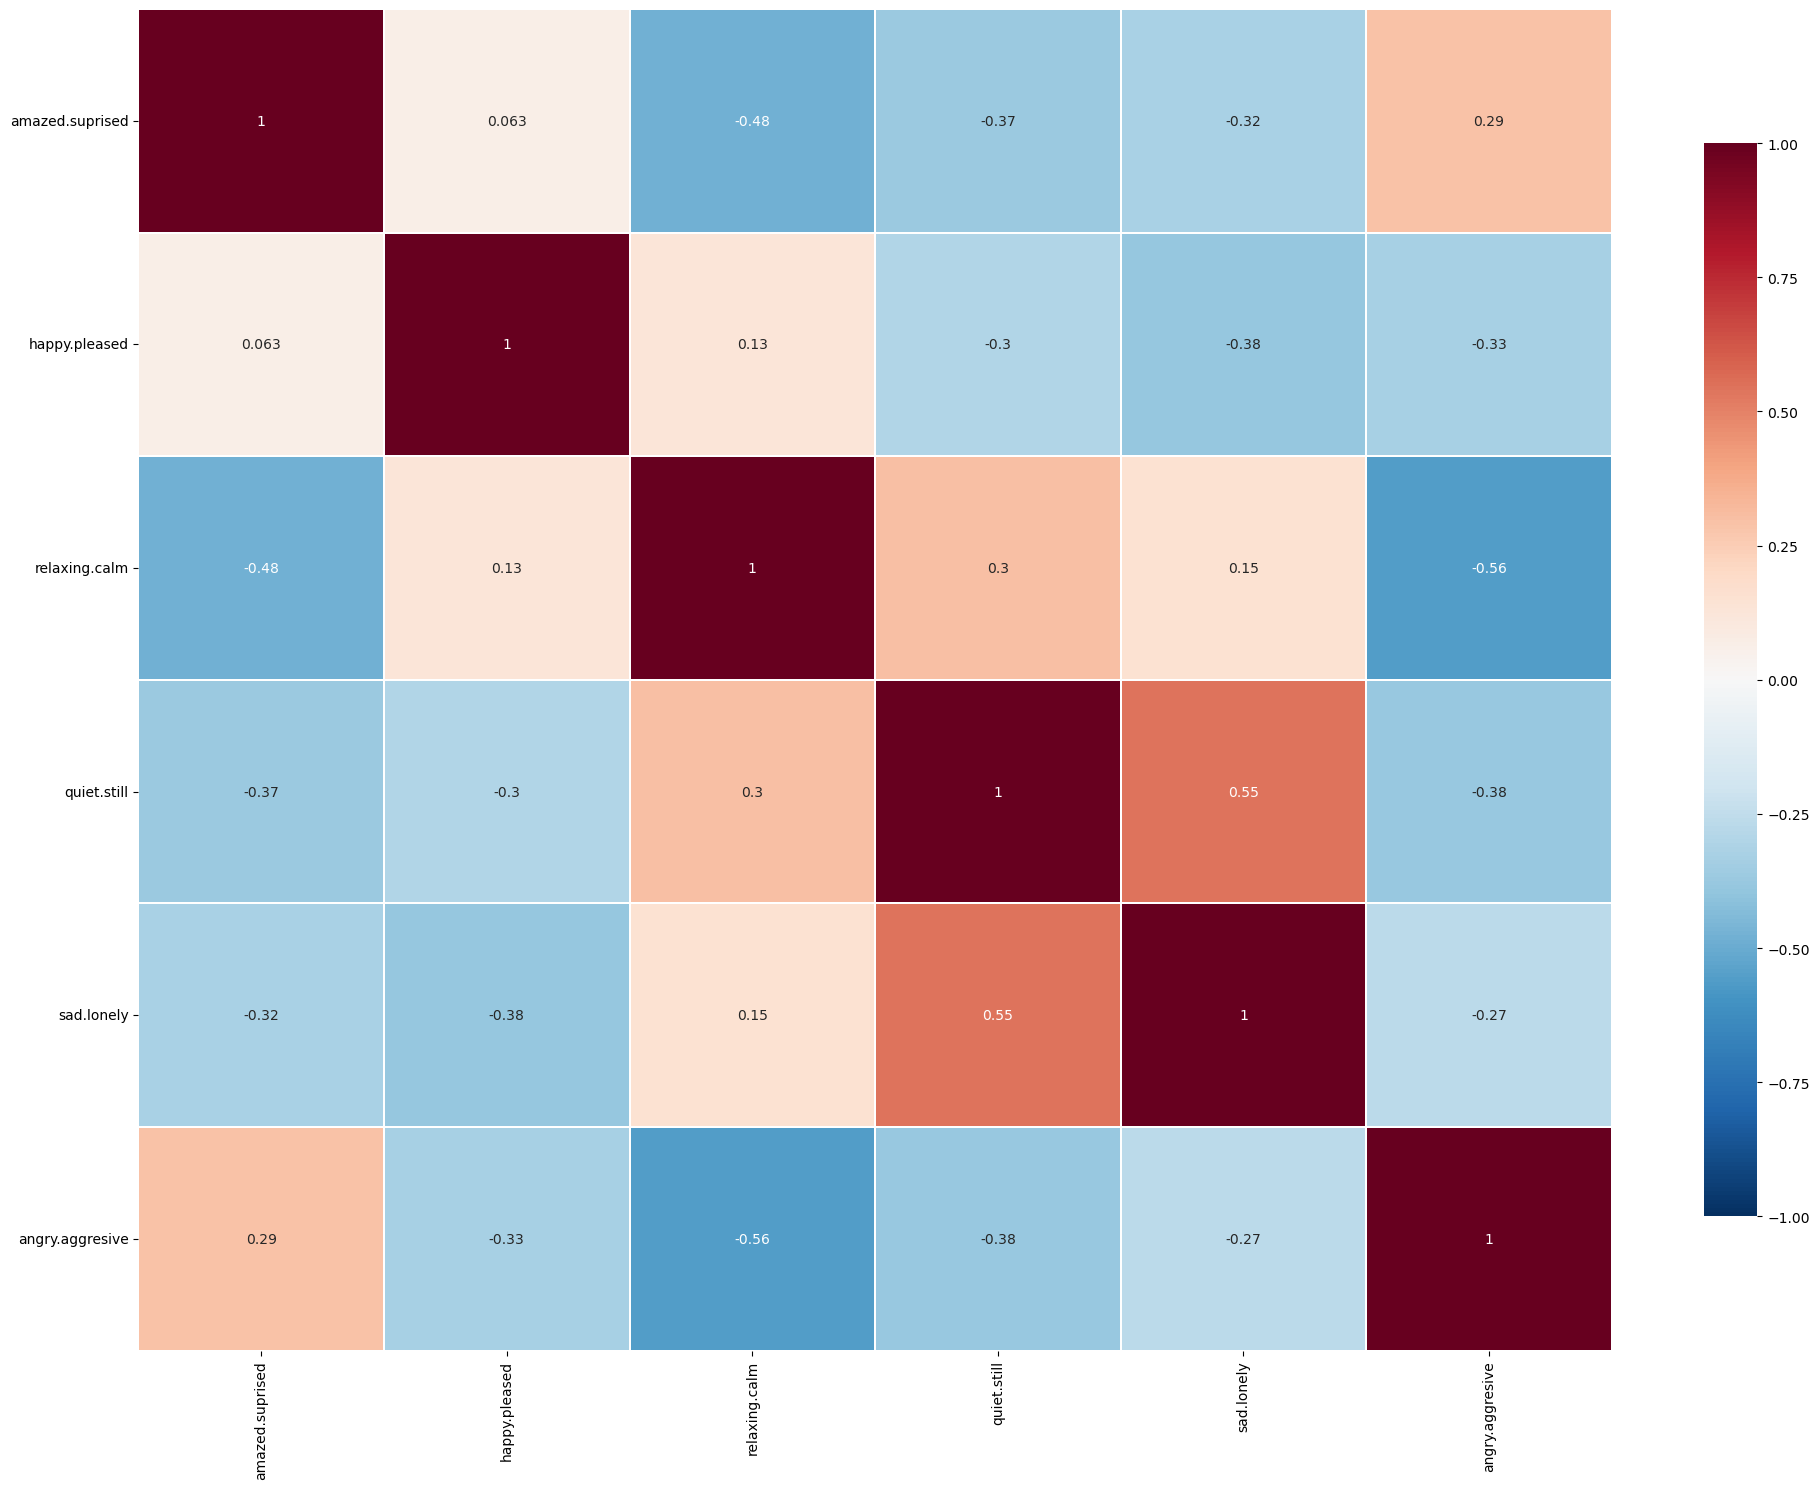

In [7]:
corr_labels=Y.corr()
plot_correlation_matrix(corr_labels)

In [8]:
for i in range(Y.shape[1]):
    print(f"Label {Y.columns[i]} is present in {np.sum(Y.iloc[:,i])} out of {Y.shape[0]} observations")

Label amazed.suprised is present in 173 out of 593 observations
Label happy.pleased is present in 166 out of 593 observations
Label relaxing.calm is present in 264 out of 593 observations
Label quiet.still is present in 148 out of 593 observations
Label sad.lonely is present in 168 out of 593 observations
Label angry.aggresive is present in 189 out of 593 observations


(array([0., 0., 0., 1., 0., 0.]),
 array([0.5       , 0.66666667, 0.83333333, 1.        , 1.16666667,
        1.33333333, 1.5       ]),
 <BarContainer object of 6 artists>)

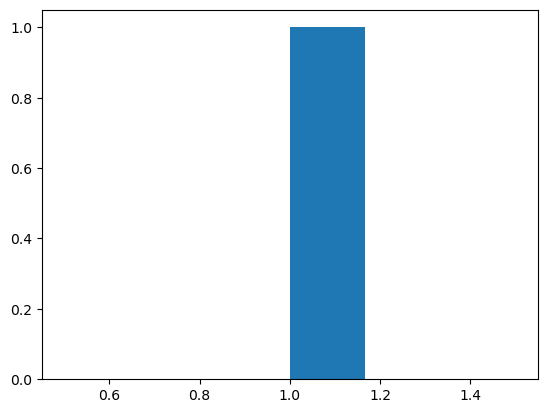

In [14]:
active_ct=np.zeros(Y.shape[0])
for i in range(Y.shape[0]):
    active_ct=np.sum(Y.iloc[i,:])

In [13]:
y_cumulated=np.zeros(Y.shape[0])
for i in range(Y.shape[0]):
    for j in range(Y.shape[1]):
        y_cumulated[i]=y_cumulated[i]*10+Y.iloc[i,j]
y_cumulated=y_cumulated.astype(int)


11000
